[Iter 0100] σ=0.100 log p(x_T) quartiles=(-10.91,-6.14,-3.30) IQR=7.61 | actor=0.000 critic=20.010 ratio=1.000 H=-1.767
   ↳ components_hit=4/4 | top mass=0.275 | bottom mass=0.233 | MMD²=5.4419e-04
[Iter 0200] σ=0.100 log p(x_T) quartiles=(-8.75,-4.83,-2.83) IQR=5.92 | actor=-0.001 critic=13.414 ratio=1.002 H=-1.767
   ↳ components_hit=4/4 | top mass=0.252 | bottom mass=0.248 | MMD²=-3.9339e-05
[Iter 0300] σ=0.100 log p(x_T) quartiles=(-7.11,-4.13,-2.46) IQR=4.65 | actor=-0.003 critic=11.260 ratio=0.999 H=-1.767
   ↳ components_hit=4/4 | top mass=0.263 | bottom mass=0.234 | MMD²=6.9833e-04
[Iter 0400] σ=0.100 log p(x_T) quartiles=(-6.53,-3.72,-2.36) IQR=4.17 | actor=-0.004 critic=5.320 ratio=1.003 H=-1.767
   ↳ components_hit=4/4 | top mass=0.267 | bottom mass=0.232 | MMD²=6.7151e-04
[Iter 0500] σ=0.100 log p(x_T) quartiles=(-6.72,-3.87,-2.36) IQR=4.36 | actor=-0.001 critic=5.893 ratio=1.000 H=-1.767
   ↳ components_hit=4/4 | top mass=0.263 | bottom mass=0.238 | MMD²=4.6492e-06
[Iter 

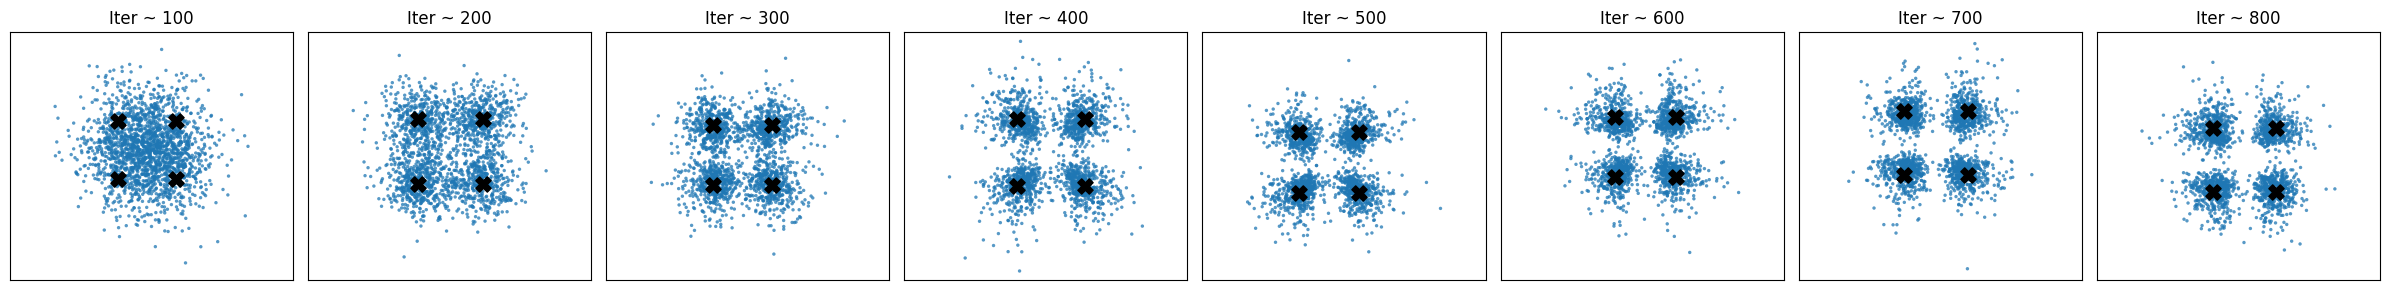

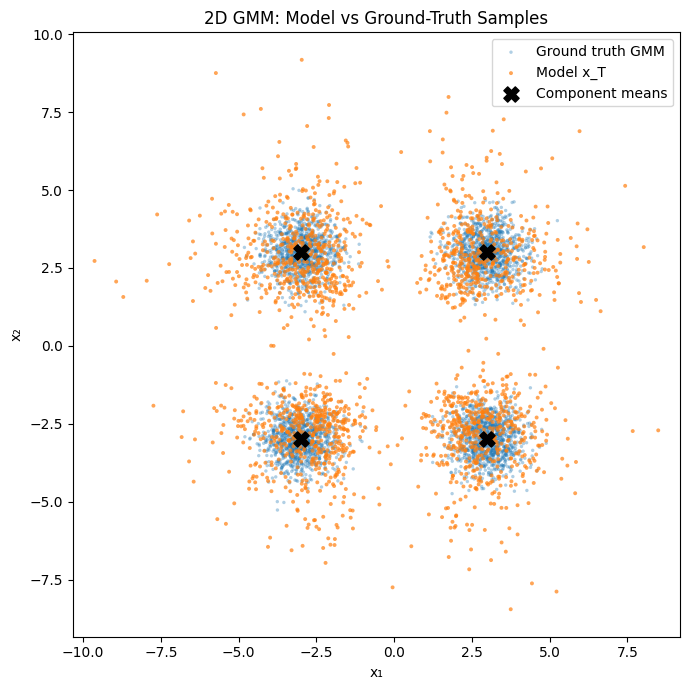

In [ ]:
# =========================================================
# PPO-RLFS for 4-Component 2D GMM (with Ground-Truth Sampling & Visualization)
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Target: 4-Component GMM in 2D
# =========================================================
D = 2
K = 4
COMP_STD = 0.6  # per-component std (isotropic)
COMP_VAR = COMP_STD ** 2

# Means: corners of a square grid at (+/-3, +/-3)
MEANS = jnp.array([[+3.0, +3.0],
                   [+3.0, -3.0],
                   [-3.0, +3.0],
                   [-3.0, -3.0]])  # (K, D)
WEIGHTS = jnp.ones((K,)) / K       # uniform

def log_gaussian_iso(x, mean, var):
    # x: (..., D), mean: (D,), var: scalar
    diff = x - mean
    quad = jnp.sum(diff * diff, axis=-1) / var
    return -0.5 * quad

def log_mixture(x, means=MEANS, weights=WEIGHTS, var=COMP_VAR):
    # Stable logsumexp over K components
    # x: (..., D)
    def comp_logprob(m):
        return log_gaussian_iso(x, m, var)  # (...,)
    comp_vals = jax.vmap(comp_logprob, in_axes=(0,))(means)  # (K, ...)
    logw = jnp.log(weights)[:, None]  # (K, 1 or ...)
    z = comp_vals + logw              # (K, ...)
    z_max = jnp.max(z, axis=0, keepdims=True)
    return jnp.squeeze(z_max,0) + jnp.log(jnp.sum(jnp.exp(z - z_max), axis=0))

def log_unnormalized_pi(x):
    # True normalized log-density of the GMM; safe to use directly as terminal reward
    return log_mixture(x)

def estimate_logZ_IS(key, N=4000):
    # Proposal q: the TRUE (normalized) GMM; we can sample and evaluate it
    x = sample_gmm(key, N)  # x ~ q
    logq = log_mixture(x)          # log q(x)
    logf = log_unnormalized_pi(x)         # log f(x) (unnormalized target)
    # logZ_hat = log mean exp(logf - logq)
    vals = logf - logq
    m = jnp.max(vals)
    logZ_hat = m + jnp.log(jnp.mean(jnp.exp(vals - m)))
    return logZ_hat

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

def sample_gmm(key, n, means=MEANS, weights=WEIGHTS, std=COMP_STD):
    # Draw ground-truth samples from the mixture
    key_idx, key_eps = random.split(key)
    idx = random.categorical(key_idx, jnp.log(weights), shape=(n,))  # (n,)
    mu = means[idx]                                                  # (n, D)
    eps = random.normal(key_eps, (n, D)) * std
    return mu + eps                                                  # (n, D)

# =========================================================
# 2. RLFS transition (same structure; smaller integration step = 1.0)
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Forward/backward KL reward step (matching your original structure)."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t

    # Forward density F(x_{t+1}|x_t) = N(x_t + mu_t, sigma^2 I)
    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sig2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sig2, axis=1)

    # Backward proposal B(x_t|x_{t+1}) = N(sqrt(1-sigma^2) x_{t+1}, sigma^2 I)
    coef = jnp.sqrt(jnp.clip(1.0 - sigma**2, 1e-8, 1.0))
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sig2, axis=1)

    r_t = logB - logF
    # Action logprob under N(mu_t, sigma^2 I)
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# 3. Networks
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out


class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 4. MMD (same robust median heuristic)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

# Component “coverage”: assign to nearest mean (Euclidean) for a quick proxy
def component_assignments(x, means=MEANS):
    # x: (N, D)
    diffs = x[:, None, :] - means[None, :, :]  # (N, K, D)
    d2 = jnp.sum(diffs**2, axis=-1)            # (N, K)
    return jnp.argmin(d2, axis=-1)             # (N,)

def coverage_stats(x, K=K):
    idx = component_assignments(x)
    counts = jnp.bincount(idx, length=K)
    freq = counts / jnp.maximum(jnp.sum(counts), 1)
    n_hit = jnp.sum(counts > 0)
    return int(n_hit), freq

# =========================================================
# 5. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    # Start near origin (hard for well-separated GMM)
    x0 = 3.0 * random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))
    # Terminal reward from true GMM
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    # True terminal (no bootstrap)
    v_T = jnp.zeros((BATCH,))

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj

def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 6. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    s1 = ratio * adv_norm
    s2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(s1, s2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total, aux

# =========================================================
# 7. Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=500):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.01, boosted_coef=0.05):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

# =========================================================
# 8. Training
# =========================================================
def train_gmm_ppo(rng_key=random.PRNGKey(0), D=2, BATCH=1024, T=T_HORIZON,
                  actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                  clip_eps=0.2, NITER=2000, MINIBATCH=8192):

    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic, key_ref = random.split(rng_key, 4)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params = actor.init(key_actor, dummy_x, dummy_t)
    critic_params = critic.init(key_critic, dummy_x, dummy_t)

    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state  = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)

    # Ground-truth reference samples from the true GMM
    ref_samples = sample_gmm(key_ref, 4000)
    snapshots = []   # NEW: store up to ~8 snapshots

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        a_grads, a_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        c_grads, c_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_a = actor_state.apply_gradients(grads=a_grads)
        new_c = critic_state.apply_gradients(grads=c_grads)
        aux = {"actor_loss": a_aux["actor_loss"],
               "critic_loss": c_aux["critic_loss"],
               "ratio_mean": a_aux["ratio_mean"],
               "entropy": a_aux["entropy"]}
        return new_a, new_c, aux

    last_xT = None
    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )
        last_xT = x_T  # keep for plotting after training

        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)

        if it % 100 == 0:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            mmd2_val = float(mmd_unbiased_rbf(last_xT[:1000], ref_samples[:1000]))
            n_hit, freq = coverage_stats(last_xT, K=K)
            top, bottom = float(jnp.max(freq)), float(jnp.min(freq))
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log p(x_T) quartiles=({q1:.2f},{q2:.2f},{q3:.2f}) "
                  f"IQR={iqr:.2f} | actor={aux['actor_loss']:.3f} critic={aux['critic_loss']:.3f} "
                  f"ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")
            print(f"   ↳ components_hit={n_hit}/{K} | top mass={top:.3f} | bottom mass={bottom:.3f} | MMD²={mmd2_val:.4e}")

        if (it % 100 == 0 or it == 1) and len(snapshots) < 11:
            snapshots.append(np.array(last_xT[:2000]))   # store only 2000 points


    return actor_state, critic_state, last_xT, ref_samples, snapshots

# =========================================================
# 9. Visualization (2D): true GMM density + samples
# =========================================================
def visualize_2d_samples(model_samples, ref_samples, means=MEANS):
    ms = np.array(model_samples)
    rs = np.array(ref_samples)

    plt.figure(figsize=(7,7))

    # Ground-truth samples (light)
    plt.scatter(rs[:,0], rs[:,1], s=6, alpha=0.35,
                label="Ground truth GMM", edgecolors='none')

    # Model samples (darker)
    plt.scatter(ms[:,0], ms[:,1], s=8, alpha=0.7,
                label="Model x_T", edgecolors='none')

    # Component means (optional)
    M = np.array(means)
    plt.scatter(M[:,0], M[:,1], s=120, marker='X', c='black', label="Component means")

    plt.legend(loc="upper right")
    plt.title("2D GMM: Model vs Ground-Truth Samples")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

def plot_convergence_grid(snapshots, means=MEANS):
    import matplotlib.pyplot as plt
    n = len(snapshots)
    plt.figure(figsize=(3*n, 3))

    for i, s in enumerate(snapshots):
        plt.subplot(1, n, i+1)
        plt.scatter(s[:,0], s[:,1], s=6, alpha=0.75, edgecolors='none')
        plt.scatter(means[:,0], means[:,1], s=120, marker='X', c='black')
        plt.title(f"Iter ~ {(i+1)*100}")
        plt.axis("equal")
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
  # 1) Get initial x_T before learning
    actor_state, critic_state, model_xT, ref_samples, snapshots = train_gmm_ppo(
        rng_key=random.PRNGKey(0),
        D=D,
        BATCH=2000,
        T=32,
        actor_lr=1e-5,
        critic_lr=1e-5,
        ppo_epochs=3,
        clip_eps=0.2,
        NITER=700,       # feel free to increase to 4000+
        MINIBATCH=4800
    )

    # NEW: Show how RLFS gradually discovers all four modes
    plot_convergence_grid(snapshots)

    # Visualize true GMM + model vs ground-truth samples
    visualize_2d_samples(model_xT[:4000], ref_samples[:4000])


In [ ]:

# =========================================================
# Sinkhorn divergence (reusing your stable formulation)
# =========================================================
import jax
import jax.numpy as jnp
from jax import lax
from jax.scipy.special import logsumexp

def pairwise_sq_dists(X, Y):
    X2 = jnp.sum(X**2, axis=1, keepdims=True)
    Y2 = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X2 + Y2 - 2.0 * (X @ Y.T)

def _sinkhorn_cost_logdomain(C, a, b, eps, n_iters):
    log_a = jnp.log(a)
    log_b = jnp.log(b)
    f = jnp.zeros_like(a)
    g = jnp.zeros_like(b)

    def body(_, state):
        f, g = state
        term_f = (g[None,:] - C) / eps + log_b[None,:]
        f = eps * (log_a - logsumexp(term_f, axis=1))
        term_g = (f[:,None] - C) / eps + log_a[:,None]
        g = eps * (log_b - logsumexp(term_g, axis=0))
        return (f, g)

    f, g = lax.fori_loop(0, n_iters, body, (f,g))
    return jnp.sum(a * f) + jnp.sum(b * g)

def sinkhorn_divergence(X, Y, eps=1e-2, n_iters=100):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    N, M = X.shape[0], Y.shape[0]
    a = jnp.full((N,), 1.0 / N)
    b = jnp.full((M,), 1.0 / M)
    C_xy = pairwise_sq_dists(X, Y)
    C_xx = pairwise_sq_dists(X, X)
    C_yy = pairwise_sq_dists(Y, Y)
    W_xy = _sinkhorn_cost_logdomain(C_xy, a, b, eps, n_iters)
    W_xx = _sinkhorn_cost_logdomain(C_xx, a, a, eps, n_iters)
    W_yy = _sinkhorn_cost_logdomain(C_yy, b, b, eps, n_iters)
    return W_xy - 0.5 * (W_xx + W_yy)

def standardize_for_eval(X, Y):
    mean = jnp.mean(Y, axis=0, keepdims=True)
    std  = jnp.std(Y, axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, (Y - mean) / std


# model_xT: final RLFS samples returned from train_gmm_ppo
# ref_samples: true GMM samples

# Standardize both
X_eval, Y_eval = standardize_for_eval(model_xT[:2000], ref_samples[:2000])

# Compute metrics
mmd2 = mmd_unbiased_rbf(X_eval, Y_eval)               # already defined in your code
sink = sinkhorn_divergence(X_eval, Y_eval, eps=1e-3, n_iters=100)

print(f"\n================ Evaluation ================")
print(f"MMD²              = {float(mmd2):.6f}")
print(f"Sinkhorn Divergence = {float(sink):.6f}")
print("==========================================\n")



================ Evaluation ================
MMD²              = 0.000505
Sinkhorn Divergence = 0.084771



## Main to get result


In [1]:
# =========================================================
# PPO-RLFS for 4-Component 2D GMM (with Ground-Truth Sampling & Visualization)
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Target: 4-Component GMM in 2D
# =========================================================
D = 2
K = 4
COMP_STD = 0.6  # per-component std (isotropic)
COMP_VAR = COMP_STD ** 2

# Means: corners of a square grid at (+/-3, +/-3)
MEANS = jnp.array([[+3.0, +3.0],
                   [+3.0, -3.0],
                   [-3.0, +3.0],
                   [-3.0, -3.0]])  # (K, D)
WEIGHTS = jnp.ones((K,)) / K       # uniform

def log_gaussian_iso(x, mean, var):
    # x: (..., D), mean: (D,), var: scalar
    diff = x - mean
    quad = jnp.sum(diff * diff, axis=-1) / var
    return -0.5 * quad

def log_mixture(x, means=MEANS, weights=WEIGHTS, var=COMP_VAR):
    # Stable logsumexp over K components
    # x: (..., D)
    def comp_logprob(m):
        return log_gaussian_iso(x, m, var)  # (...,)
    comp_vals = jax.vmap(comp_logprob, in_axes=(0,))(means)  # (K, ...)
    logw = jnp.log(weights)[:, None]  # (K, 1 or ...)
    z = comp_vals + logw              # (K, ...)
    z_max = jnp.max(z, axis=0, keepdims=True)
    return jnp.squeeze(z_max,0) + jnp.log(jnp.sum(jnp.exp(z - z_max), axis=0))

def log_unnormalized_pi(x):
    # True normalized log-density of the GMM; safe to use directly as terminal reward
    return log_mixture(x)

def estimate_logZ_IS(key, N=4000):
    # Proposal q: the TRUE (normalized) GMM; we can sample and evaluate it
    x = sample_gmm(key, N)  # x ~ q
    logq = log_mixture(x)          # log q(x)
    logf = log_unnormalized_pi(x)         # log f(x) (unnormalized target)
    # logZ_hat = log mean exp(logf - logq)
    vals = logf - logq
    m = jnp.max(vals)
    logZ_hat = m + jnp.log(jnp.mean(jnp.exp(vals - m)))
    return logZ_hat

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

def sample_gmm(key, n, means=MEANS, weights=WEIGHTS, std=COMP_STD):
    # Draw ground-truth samples from the mixture
    key_idx, key_eps = random.split(key)
    idx = random.categorical(key_idx, jnp.log(weights), shape=(n,))  # (n,)
    mu = means[idx]                                                  # (n, D)
    eps = random.normal(key_eps, (n, D)) * std
    return mu + eps                                                  # (n, D)

# =========================================================
# 2. RLFS transition (same structure; smaller integration step = 1.0)
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Forward/backward KL reward step (matching your original structure)."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t

    # Forward density F(x_{t+1}|x_t) = N(x_t + mu_t, sigma^2 I)
    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sig2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sig2, axis=1)

    # Backward proposal B(x_t|x_{t+1}) = N(sqrt(1-sigma^2) x_{t+1}, sigma^2 I)
    coef = jnp.sqrt(jnp.clip(1.0 - sigma**2, 1e-8, 1.0))
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sig2, axis=1)

    r_t = logB - logF
    # Action logprob under N(mu_t, sigma^2 I)
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# 3. Networks
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out


class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 4. MMD (same robust median heuristic)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

# Component “coverage”: assign to nearest mean (Euclidean) for a quick proxy
def component_assignments(x, means=MEANS):
    # x: (N, D)
    diffs = x[:, None, :] - means[None, :, :]  # (N, K, D)
    d2 = jnp.sum(diffs**2, axis=-1)            # (N, K)
    return jnp.argmin(d2, axis=-1)             # (N,)

def coverage_stats(x, K=K):
    idx = component_assignments(x)
    counts = jnp.bincount(idx, length=K)
    freq = counts / jnp.maximum(jnp.sum(counts), 1)
    n_hit = jnp.sum(counts > 0)
    return int(n_hit), freq

# =========================================================
# 5. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    # Start near origin (hard for well-separated GMM)
    x0 = 3.0 * random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))
    # Terminal reward from true GMM
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    # True terminal (no bootstrap)
    v_T = jnp.zeros((BATCH,))

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj

def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 6. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    s1 = ratio * adv_norm
    s2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(s1, s2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total, aux

# =========================================================
# 7. Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=500):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.01, boosted_coef=0.05):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

# =========================================================
# 8. Training
# =========================================================
def train_gmm_ppo(rng_key=random.PRNGKey(0), D=2, BATCH=1024, T=T_HORIZON,
                  actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                  clip_eps=0.2, NITER=2000, MINIBATCH=8192):

    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic, key_ref = random.split(rng_key, 4)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params = actor.init(key_actor, dummy_x, dummy_t)
    critic_params = critic.init(key_critic, dummy_x, dummy_t)

    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state  = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)

    # Ground-truth reference samples from the true GMM
    ref_samples = sample_gmm(key_ref, 4000)
    snapshots = []   # NEW: store up to ~8 snapshots

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        a_grads, a_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        c_grads, c_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_a = actor_state.apply_gradients(grads=a_grads)
        new_c = critic_state.apply_gradients(grads=c_grads)
        aux = {"actor_loss": a_aux["actor_loss"],
               "critic_loss": c_aux["critic_loss"],
               "ratio_mean": a_aux["ratio_mean"],
               "entropy": a_aux["entropy"]}
        return new_a, new_c, aux

    last_xT = None
    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )
        last_xT = x_T  # keep for plotting after training

        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)

        if it % 100 == 0:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            mmd2_val = float(mmd_unbiased_rbf(last_xT[:1000], ref_samples[:1000]))
            n_hit, freq = coverage_stats(last_xT, K=K)
            top, bottom = float(jnp.max(freq)), float(jnp.min(freq))
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log p(x_T) quartiles=({q1:.2f},{q2:.2f},{q3:.2f}) "
                  f"IQR={iqr:.2f} | actor={aux['actor_loss']:.3f} critic={aux['critic_loss']:.3f} "
                  f"ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")
            print(f"   ↳ components_hit={n_hit}/{K} | top mass={top:.3f} | bottom mass={bottom:.3f} | MMD²={mmd2_val:.4e}")



    return actor_state, critic_state, last_xT, ref_samples


# =========================================================
# Sinkhorn divergence (reusing your stable formulation)
# =========================================================
import jax
import jax.numpy as jnp
from jax import lax
from jax.scipy.special import logsumexp

def pairwise_sq_dists(X, Y):
    X2 = jnp.sum(X**2, axis=1, keepdims=True)
    Y2 = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X2 + Y2 - 2.0 * (X @ Y.T)

def _sinkhorn_cost_logdomain(C, a, b, eps, n_iters):
    log_a = jnp.log(a)
    log_b = jnp.log(b)
    f = jnp.zeros_like(a)
    g = jnp.zeros_like(b)

    def body(_, state):
        f, g = state
        term_f = (g[None,:] - C) / eps + log_b[None,:]
        f = eps * (log_a - logsumexp(term_f, axis=1))
        term_g = (f[:,None] - C) / eps + log_a[:,None]
        g = eps * (log_b - logsumexp(term_g, axis=0))
        return (f, g)

    f, g = lax.fori_loop(0, n_iters, body, (f,g))
    return jnp.sum(a * f) + jnp.sum(b * g)

def sinkhorn_divergence(X, Y, eps=1e-2, n_iters=100):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    N, M = X.shape[0], Y.shape[0]
    a = jnp.full((N,), 1.0 / N)
    b = jnp.full((M,), 1.0 / M)
    C_xy = pairwise_sq_dists(X, Y)
    C_xx = pairwise_sq_dists(X, X)
    C_yy = pairwise_sq_dists(Y, Y)
    W_xy = _sinkhorn_cost_logdomain(C_xy, a, b, eps, n_iters)
    W_xx = _sinkhorn_cost_logdomain(C_xx, a, a, eps, n_iters)
    W_yy = _sinkhorn_cost_logdomain(C_yy, b, b, eps, n_iters)
    return W_xy - 0.5 * (W_xx + W_yy)

def standardize_for_eval(X, Y):
    mean = jnp.mean(Y, axis=0, keepdims=True)
    std  = jnp.std(Y, axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, (Y - mean) / std

# =========================================================
# Multi-run evaluation (10 seeds) for GMM RLFS sampler
# =========================================================

def evaluate_run(rng_key, n_eval=2000, n_ref=2000):
    actor_state, critic_state, model_xT, ref_samples = train_gmm_ppo(
        rng_key=rng_key,
        D=D,
        BATCH=2000,
        T=T_HORIZON,
        actor_lr=1e-5,
        critic_lr=1e-5,
        ppo_epochs=3,
        clip_eps=0.2,
        NITER=800,
        MINIBATCH=4800
    )

    # Take evaluation subsets
    X = model_xT[:n_eval]
    Y = ref_samples[:n_ref]

    # Standardize
    X_eval, Y_eval = standardize_for_eval(X, Y)

    # Metrics
    mmd2 = float(mmd_unbiased_rbf(X_eval, Y_eval))
    sink = float(sinkhorn_divergence(X_eval, Y_eval, eps=1e-3, n_iters=100))

    # Mode coverage
    n_hit, freq = coverage_stats(X)
    top_mass = float(jnp.max(freq))
    bottom_mass = float(jnp.min(freq))

    return mmd2, sink, n_hit, top_mass, bottom_mass

def run_multiple(seeds=10):
    results = []

    for i in range(seeds):
        print(f"\n===== RUN {i+1}/{seeds} =====")
        key = random.PRNGKey(12345 + i)
        mmd2, sink, n_hit, top_mass, bottom_mass = evaluate_run(key)

        print(f"MMD² = {mmd2:.6f} | Sinkhorn = {sink:.6f} "
              f"| Modes Hit = {n_hit} "
              f"| Top Mass = {top_mass:.3f} | Bottom Mass = {bottom_mass:.3f}")

        results.append([mmd2, sink, n_hit, top_mass, bottom_mass])

    results = np.array(results)
    mean = results.mean(axis=0)
    std  = results.std(axis=0)

    print("\n================ Summary Over All Runs ================")
    print(f"MMD²            : {mean[0]:.6f} ± {std[0]:.6f}")
    print(f"Sinkhorn        : {mean[1]:.6f} ± {std[1]:.6f}")
    print(f"Modes Hit       : {mean[2]:.2f} ± {std[2]:.2f}")
    print(f"Top Mass        : {mean[3]:.3f} ± {std[3]:.3f}")
    print(f"Bottom Mass     : {mean[4]:.3f} ± {std[4]:.3f}")
    print("=======================================================\n")

    return results, mean, std


# =========================================================
# MAIN: Run 10 evaluations
# =========================================================
if __name__ == "__main__":
    results, mean, std = run_multiple(seeds=10)



===== RUN 1/10 =====
[Iter 0100] σ=0.100 log p(x_T) quartiles=(-11.42,-6.62,-3.50) IQR=7.92 | actor=0.001 critic=19.991 ratio=1.001 H=-1.767
   ↳ components_hit=4/4 | top mass=0.270 | bottom mass=0.227 | MMD²=1.0220e-03
[Iter 0200] σ=0.100 log p(x_T) quartiles=(-9.22,-5.07,-2.76) IQR=6.47 | actor=-0.002 critic=12.618 ratio=0.999 H=-1.767
   ↳ components_hit=4/4 | top mass=0.254 | bottom mass=0.245 | MMD²=-3.5048e-04
[Iter 0300] σ=0.100 log p(x_T) quartiles=(-7.44,-4.27,-2.53) IQR=4.91 | actor=-0.002 critic=7.480 ratio=1.000 H=-1.767
   ↳ components_hit=4/4 | top mass=0.271 | bottom mass=0.240 | MMD²=-3.2496e-04
[Iter 0400] σ=0.100 log p(x_T) quartiles=(-7.12,-3.88,-2.43) IQR=4.69 | actor=-0.002 critic=8.597 ratio=0.998 H=-1.767
   ↳ components_hit=4/4 | top mass=0.265 | bottom mass=0.234 | MMD²=-2.6858e-04
[Iter 0500] σ=0.100 log p(x_T) quartiles=(-6.04,-3.74,-2.32) IQR=3.72 | actor=-0.000 critic=3.157 ratio=1.001 H=-1.767
   ↳ components_hit=4/4 | top mass=0.257 | bottom mass=0.244 |

## Generate plot


[Iter 0100] σ=0.100 log p(x_T) quartiles=(-10.91,-6.14,-3.30) IQR=7.62 | actor=0.000 critic=20.022 ratio=1.000 H=-1.767
   ↳ components_hit=4/4 | top mass=0.275 | bottom mass=0.233 | MMD²=5.4455e-04
[Iter 0200] σ=0.100 log p(x_T) quartiles=(-8.73,-4.82,-2.83) IQR=5.90 | actor=-0.001 critic=13.380 ratio=1.002 H=-1.767
   ↳ components_hit=4/4 | top mass=0.252 | bottom mass=0.248 | MMD²=-5.0902e-05
[Iter 0300] σ=0.100 log p(x_T) quartiles=(-7.11,-4.13,-2.47) IQR=4.64 | actor=-0.003 critic=11.244 ratio=0.999 H=-1.767
   ↳ components_hit=4/4 | top mass=0.262 | bottom mass=0.234 | MMD²=6.8784e-04
[Iter 0400] σ=0.100 log p(x_T) quartiles=(-6.52,-3.72,-2.35) IQR=4.18 | actor=-0.004 critic=5.306 ratio=1.003 H=-1.767
   ↳ components_hit=4/4 | top mass=0.267 | bottom mass=0.232 | MMD²=6.6316e-04
[Iter 0500] σ=0.100 log p(x_T) quartiles=(-6.67,-3.88,-2.37) IQR=4.30 | actor=-0.001 critic=5.808 ratio=0.999 H=-1.767
   ↳ components_hit=4/4 | top mass=0.263 | bottom mass=0.238 | MMD²=4.0770e-05
[Iter 

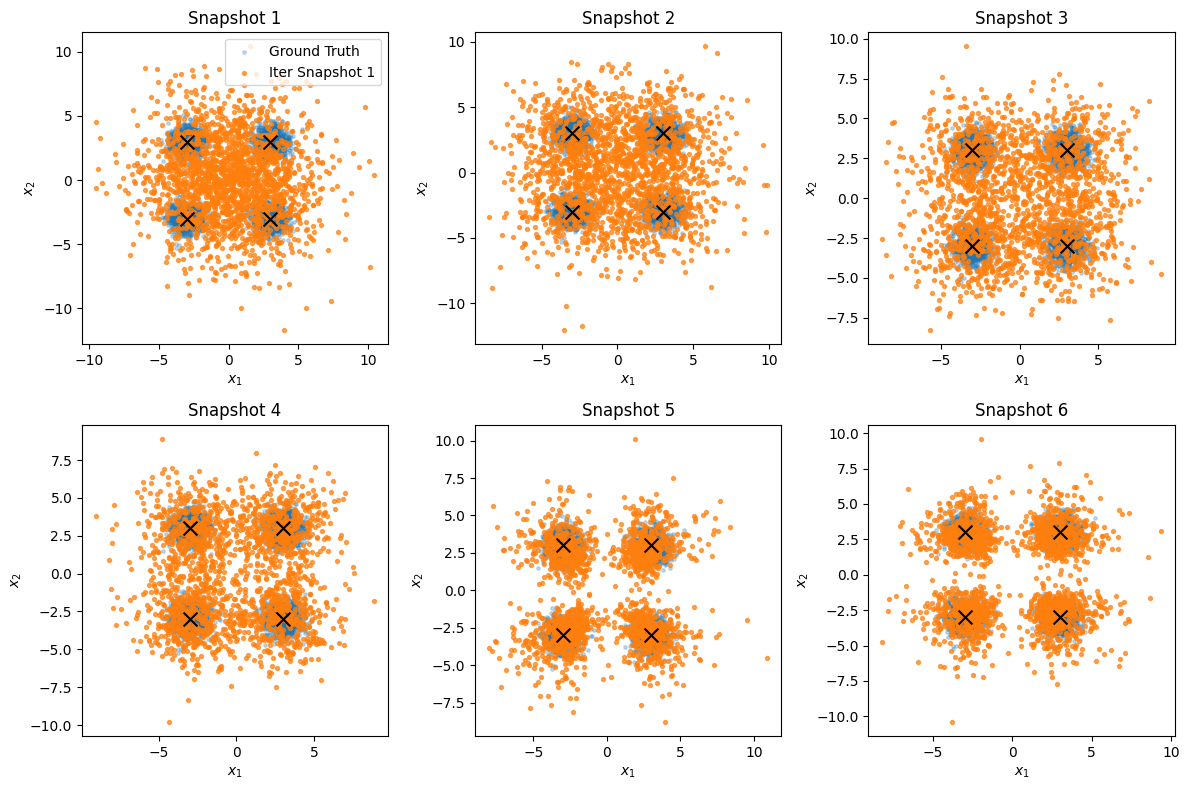

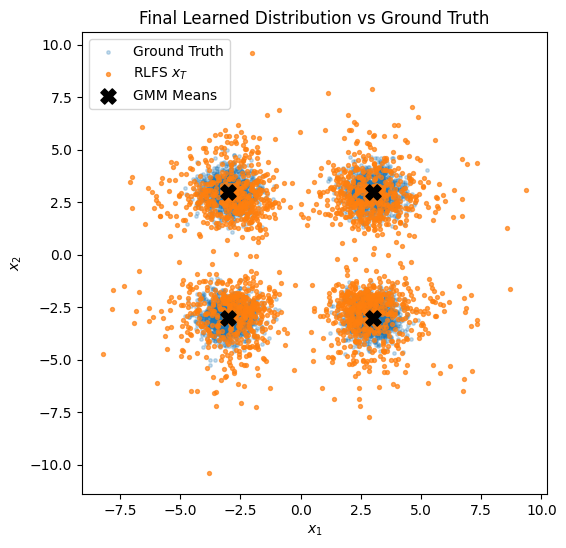

In [2]:
snapshot_iters = [1, 25, 50, 100, 400, 800]  # choose what you want to visualize

# =========================================================
# PPO-RLFS for 4-Component 2D GMM (with Ground-Truth Sampling & Visualization)
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Target: 4-Component GMM in 2D
# =========================================================
D = 2
K = 4
COMP_STD = 0.6  # per-component std (isotropic)
COMP_VAR = COMP_STD ** 2

# Means: corners of a square grid at (+/-3, +/-3)
MEANS = jnp.array([[+3.0, +3.0],
                   [+3.0, -3.0],
                   [-3.0, +3.0],
                   [-3.0, -3.0]])  # (K, D)
WEIGHTS = jnp.ones((K,)) / K       # uniform

def log_gaussian_iso(x, mean, var):
    # x: (..., D), mean: (D,), var: scalar
    diff = x - mean
    quad = jnp.sum(diff * diff, axis=-1) / var
    return -0.5 * quad

def log_mixture(x, means=MEANS, weights=WEIGHTS, var=COMP_VAR):
    # Stable logsumexp over K components
    # x: (..., D)
    def comp_logprob(m):
        return log_gaussian_iso(x, m, var)  # (...,)
    comp_vals = jax.vmap(comp_logprob, in_axes=(0,))(means)  # (K, ...)
    logw = jnp.log(weights)[:, None]  # (K, 1 or ...)
    z = comp_vals + logw              # (K, ...)
    z_max = jnp.max(z, axis=0, keepdims=True)
    return jnp.squeeze(z_max,0) + jnp.log(jnp.sum(jnp.exp(z - z_max), axis=0))

def log_unnormalized_pi(x):
    # True normalized log-density of the GMM; safe to use directly as terminal reward
    return log_mixture(x)

def estimate_logZ_IS(key, N=4000):
    # Proposal q: the TRUE (normalized) GMM; we can sample and evaluate it
    x = sample_gmm(key, N)  # x ~ q
    logq = log_mixture(x)          # log q(x)
    logf = log_unnormalized_pi(x)         # log f(x) (unnormalized target)
    # logZ_hat = log mean exp(logf - logq)
    vals = logf - logq
    m = jnp.max(vals)
    logZ_hat = m + jnp.log(jnp.mean(jnp.exp(vals - m)))
    return logZ_hat

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

def sample_gmm(key, n, means=MEANS, weights=WEIGHTS, std=COMP_STD):
    # Draw ground-truth samples from the mixture
    key_idx, key_eps = random.split(key)
    idx = random.categorical(key_idx, jnp.log(weights), shape=(n,))  # (n,)
    mu = means[idx]                                                  # (n, D)
    eps = random.normal(key_eps, (n, D)) * std
    return mu + eps                                                  # (n, D)

# =========================================================
# 2. RLFS transition (same structure; smaller integration step = 1.0)
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Forward/backward KL reward step (matching your original structure)."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t

    # Forward density F(x_{t+1}|x_t) = N(x_t + mu_t, sigma^2 I)
    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sig2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sig2, axis=1)

    # Backward proposal B(x_t|x_{t+1}) = N(sqrt(1-sigma^2) x_{t+1}, sigma^2 I)
    coef = jnp.sqrt(jnp.clip(1.0 - sigma**2, 1e-8, 1.0))
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sig2, axis=1)

    r_t = logB - logF
    # Action logprob under N(mu_t, sigma^2 I)
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# 3. Networks
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out


class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 4. MMD (same robust median heuristic)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

# Component “coverage”: assign to nearest mean (Euclidean) for a quick proxy
def component_assignments(x, means=MEANS):
    # x: (N, D)
    diffs = x[:, None, :] - means[None, :, :]  # (N, K, D)
    d2 = jnp.sum(diffs**2, axis=-1)            # (N, K)
    return jnp.argmin(d2, axis=-1)             # (N,)

def coverage_stats(x, K=K):
    idx = component_assignments(x)
    counts = jnp.bincount(idx, length=K)
    freq = counts / jnp.maximum(jnp.sum(counts), 1)
    n_hit = jnp.sum(counts > 0)
    return int(n_hit), freq

# =========================================================
# 5. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    # Start near origin (hard for well-separated GMM)
    x0 = 3.0 * random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))
    # Terminal reward from true GMM
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    # True terminal (no bootstrap)
    v_T = jnp.zeros((BATCH,))

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj

def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 6. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    s1 = ratio * adv_norm
    s2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(s1, s2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total, aux

# =========================================================
# 7. Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=500):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.01, boosted_coef=0.05):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

# =========================================================
# 8. Training
# =========================================================
def train_gmm_ppo(rng_key=random.PRNGKey(0), D=2, BATCH=1024, T=T_HORIZON,
                  actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                  clip_eps=0.2, NITER=2000, MINIBATCH=8192):

    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic, key_ref = random.split(rng_key, 4)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params = actor.init(key_actor, dummy_x, dummy_t)
    critic_params = critic.init(key_critic, dummy_x, dummy_t)

    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state  = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)

    # Ground-truth reference samples from the true GMM
    ref_samples = sample_gmm(key_ref, 4000)
    snapshots = []   # NEW: store up to ~8 snapshots

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        a_grads, a_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        c_grads, c_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_a = actor_state.apply_gradients(grads=a_grads)
        new_c = critic_state.apply_gradients(grads=c_grads)
        aux = {"actor_loss": a_aux["actor_loss"],
               "critic_loss": c_aux["critic_loss"],
               "ratio_mean": a_aux["ratio_mean"],
               "entropy": a_aux["entropy"]}
        return new_a, new_c, aux

    last_xT = None
    snapshots = []
    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )
        last_xT = x_T  # keep for plotting after training

        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)

        if it % 100 == 0:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            mmd2_val = float(mmd_unbiased_rbf(last_xT[:1000], ref_samples[:1000]))
            n_hit, freq = coverage_stats(last_xT, K=K)
            top, bottom = float(jnp.max(freq)), float(jnp.min(freq))
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log p(x_T) quartiles=({q1:.2f},{q2:.2f},{q3:.2f}) "
                  f"IQR={iqr:.2f} | actor={aux['actor_loss']:.3f} critic={aux['critic_loss']:.3f} "
                  f"ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")
            print(f"   ↳ components_hit={n_hit}/{K} | top mass={top:.3f} | bottom mass={bottom:.3f} | MMD²={mmd2_val:.4e}")

        if it in snapshot_iters:
            # Store a small subsample to avoid large memory overhead
            snapshots.append(np.array(last_xT[:2000]))

    return actor_state, critic_state, last_xT, ref_samples, snapshots


import matplotlib.pyplot as plt

def plot_learning_evolution(snapshots, ref_samples, MEANS):
    n = len(snapshots)
    cols = min(n, 3)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4*cols, 4*rows))

    for i, x in enumerate(snapshots):
        plt.subplot(rows, cols, i+1)
        plt.scatter(ref_samples[:,0], ref_samples[:,1], s=6, alpha=0.25, label="Ground Truth")
        plt.scatter(x[:,0], x[:,1], s=8, alpha=0.7, label=f"Iter Snapshot {i+1}")
        plt.scatter(MEANS[:,0], MEANS[:,1], s=100, c='black', marker='x')
        plt.title(f"Snapshot {i+1}")
        plt.xlabel("$x_1$")
        plt.ylabel("$x_2$")
        if i == 0:
            plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


def plot_final_distribution(model_xT, ref_samples, MEANS):
    plt.figure(figsize=(6,6))
    plt.scatter(ref_samples[:,0], ref_samples[:,1], s=6, alpha=0.25, label="Ground Truth")
    plt.scatter(model_xT[:,0], model_xT[:,1], s=8, alpha=0.7, label="RLFS $x_T$")
    plt.scatter(MEANS[:,0], MEANS[:,1], s=120, c='black', marker='X', label="GMM Means")
    plt.title("Final Learned Distribution vs Ground Truth")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    rng_key = random.PRNGKey(0)
    actor_state, critic_state, model_xT, ref_samples, snapshots = train_gmm_ppo(
        rng_key=rng_key,
        D=D,
        BATCH=2000,
        T=T_HORIZON,
        actor_lr=1e-5,
        critic_lr=1e-5,
        ppo_epochs=3,
        clip_eps=0.2,
        NITER=800,
        MINIBATCH=4800
    )

    plot_learning_evolution(snapshots, ref_samples, MEANS)
    plot_final_distribution(model_xT, ref_samples, MEANS)



